# 📐 SAST Prototype — Stage 2: TF-IDF Vectoriser
**MTech Project | Static Analysis Security Tool**

```
Java / Python File
        ↓
   Tokenizer
        ↓
     TF-IDF       ← YOU ARE HERE
        ↓
  Random Forest
        ↓
Safe / Vulnerable
```

This notebook converts token strings into a numeric feature matrix using **TF-IDF** (Term Frequency–Inverse Document Frequency).

## 📦 1. Imports

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

## 🔧 2. Tokenizer (reused from Stage 1)

In [2]:
def _remove_block_comments(code):
    return re.sub(r"/\*.*?\*/", " ", code, flags=re.DOTALL)

def _remove_single_line_comments(code):
    return re.sub(r"(//|#)[^\n]*", " ", code)

def _remove_string_literals(code):
    code = re.sub(r'"(?:[^"\\]|\\.)*"', " STRING_LITERAL ", code)
    code = re.sub(r"'(?:[^'\\]|\\.)*'", " STRING_LITERAL ", code)
    return code

def _split_camel_case(token):
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", token)

def tokenize(code):
    code = _remove_block_comments(code)
    code = _remove_single_line_comments(code)
    code = _remove_string_literals(code)
    tokens = re.findall(r"[A-Za-z_][A-Za-z0-9_]*", code)
    expanded = []
    for tok in tokens:
        for sub in _split_camel_case(tok).split():
            sub = sub.lower()
            if len(sub) >= 2:
                expanded.append(sub)
    return " ".join(expanded)

print("✅ Tokenizer ready.")

✅ Tokenizer ready.


## 📂 3. Load & Tokenize Dataset

In [3]:
df = pd.read_csv("dataset.csv")
df["tokens"] = df["code_snippet"].fillna("").apply(tokenize)

print(f"Shape: {df.shape}")
print(df["label"].value_counts())

Shape: (1200, 10)
label
safe                300
insecure_api        300
sql_injection       300
hardcoded_secret    300
Name: count, dtype: int64


## 🔢 4. Fit TF-IDF Vectoriser

In [4]:
tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),       # unigrams, bigrams, trigrams
    max_features=10_000,
    sublinear_tf=True,        # log(1 + tf) dampening
    min_df=2,                 # ignore very rare tokens
)

X = tfidf.fit_transform(df["tokens"])
feature_names = np.array(tfidf.get_feature_names_out())

print(f"Feature matrix shape : {X.shape}")
print(f"Vocabulary size      : {len(feature_names):,}")
print(f"Matrix sparsity      : {1 - X.nnz / (X.shape[0]*X.shape[1]):.2%}")

Feature matrix shape : (1200, 378)
Vocabulary size      : 378
Matrix sparsity      : 96.84%


## 🔝 5. Top TF-IDF Tokens per Class

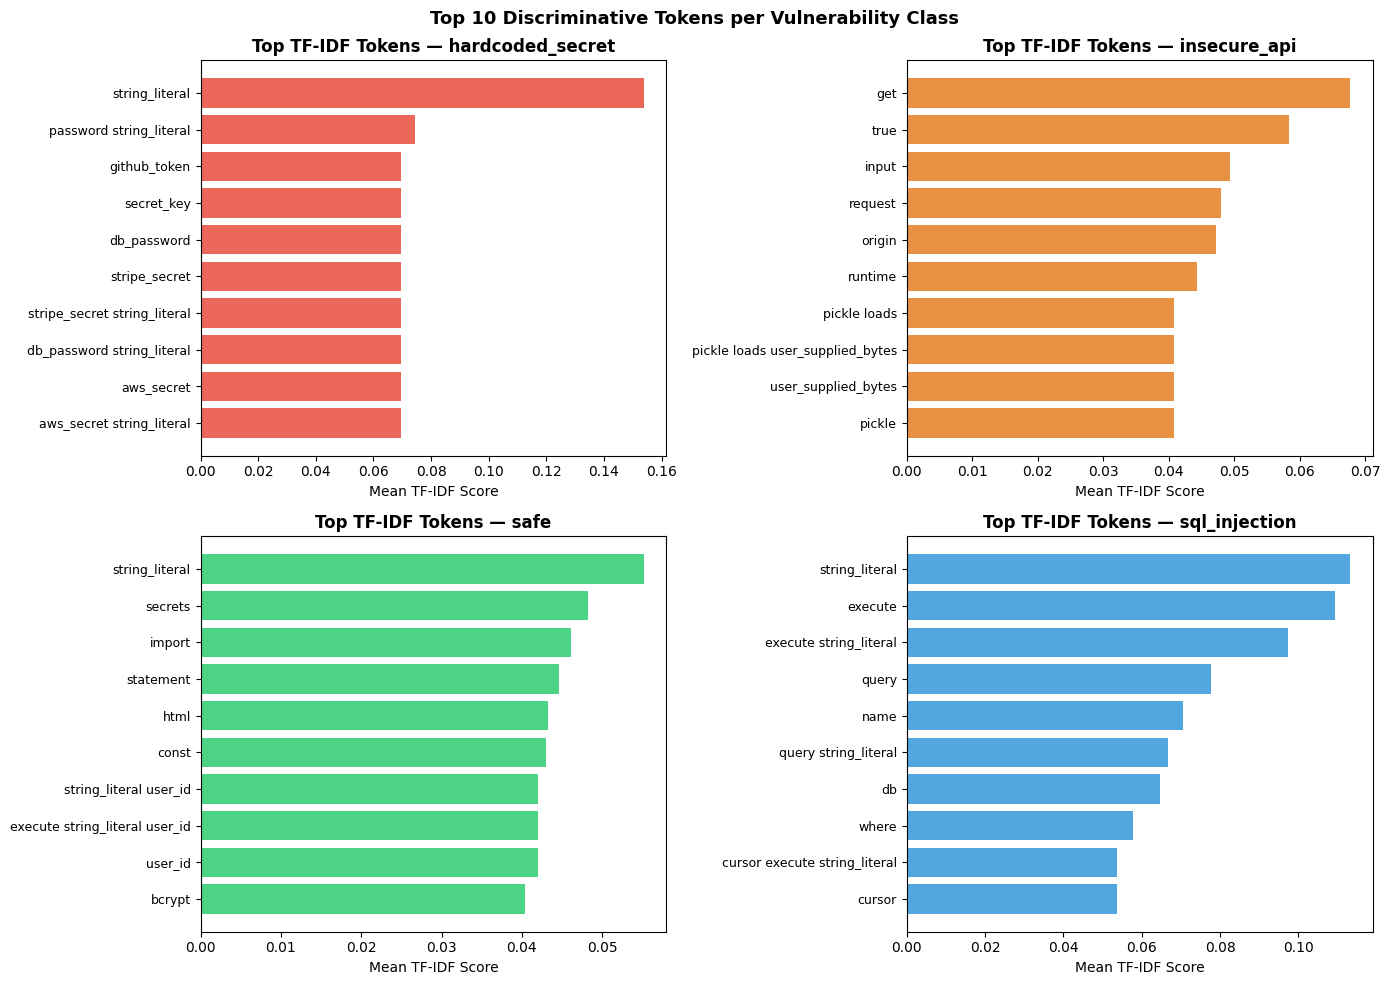

In [5]:
le = LabelEncoder()
y = le.fit_transform(df["label"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"]

for i, cls in enumerate(le.classes_):
    mask    = (df["label"] == cls).values
    X_cls   = X[mask]
    mean_tf = X_cls.mean(axis=0).A1
    top10   = np.argsort(mean_tf)[::-1][:10]

    tokens = feature_names[top10]
    scores = mean_tf[top10]

    axes[i].barh(range(10), scores[::-1], color=colors[i], alpha=0.85)
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(tokens[::-1], fontsize=9)
    axes[i].set_title(f"Top TF-IDF Tokens — {cls}", fontweight="bold")
    axes[i].set_xlabel("Mean TF-IDF Score")

plt.suptitle("Top 10 Discriminative Tokens per Vulnerability Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("tfidf_top_tokens.png", dpi=120, bbox_inches="tight")
plt.show()

## 📊 6. Feature Matrix Heatmap (sample)

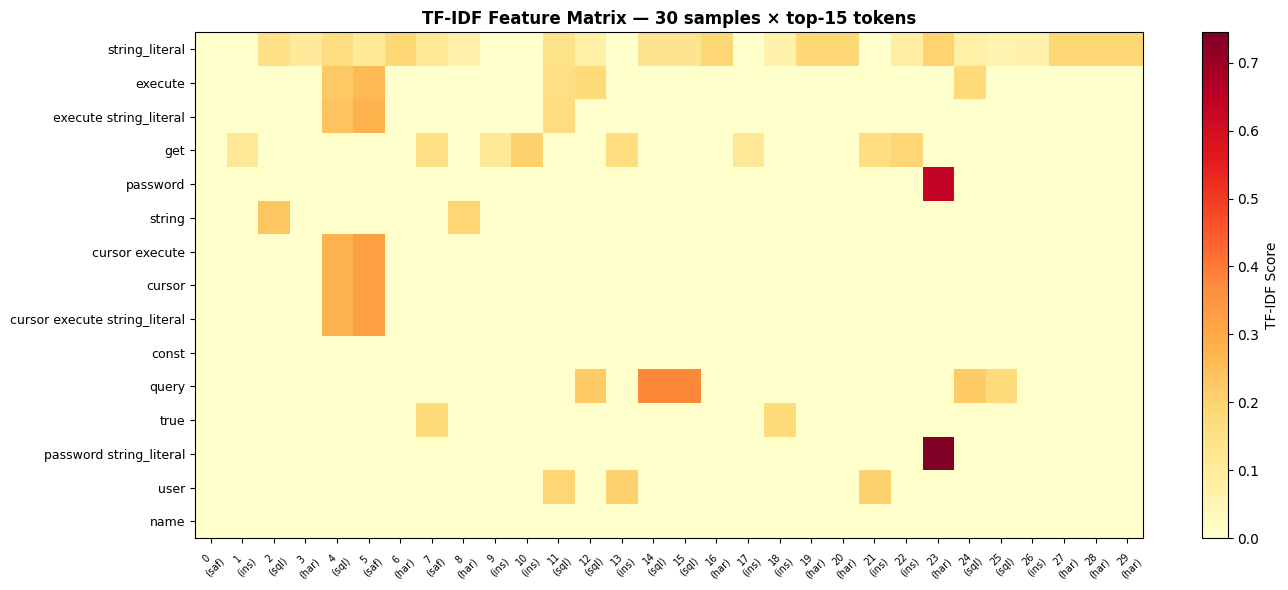

In [6]:
# Show TF-IDF scores for first 30 samples × top-15 global tokens
global_top15_idx = np.argsort(X.mean(axis=0).A1)[::-1][:15]
sample_X  = X[:30, global_top15_idx].toarray()
sample_ft = feature_names[global_top15_idx]
sample_lb = df["label"].values[:30]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(sample_X.T, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(30))
ax.set_xticklabels([f"{i}\n({l[:3]})" for i, l in enumerate(sample_lb)], fontsize=7, rotation=45)
ax.set_yticks(range(15))
ax.set_yticklabels(sample_ft, fontsize=9)
ax.set_title("TF-IDF Feature Matrix — 30 samples × top-15 tokens", fontweight="bold")
plt.colorbar(im, ax=ax, label="TF-IDF Score")
plt.tight_layout()
plt.savefig("tfidf_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 💾 7. Summary

In [7]:
import scipy.sparse as sp

print("TF-IDF Vectoriser Summary")
print("-" * 40)
print(f"Documents          : {X.shape[0]:,}")
print(f"Features (n-grams) : {X.shape[1]:,}")
print(f"Non-zero entries   : {X.nnz:,}")
print(f"Sparsity           : {1 - X.nnz/(X.shape[0]*X.shape[1]):.2%}")
print()
print("Ready to feed into Random Forest ✅")

TF-IDF Vectoriser Summary
----------------------------------------
Documents          : 1,200
Features (n-grams) : 378
Non-zero entries   : 14,340
Sparsity           : 96.84%

Ready to feed into Random Forest ✅
